# Practice 1 — From Data to Graphs: Zachary's Karate Club

### Complex Network Features: Nodes, Edges, Adjacency, Clustering Coefficient, NetworkX, Visualization

**Subject:** Social Networks (SNET)  
**Language:** English  
**Main libraries:** pandas, NetworkX, Matplotlib

## Objectives of the practice

1. Work with a real social-network database: **Zachary's Karate Club**.
2. Use **Python `pandas`** to read, inspect, and summarize an edge-list dataset.
3. Convert tabular relational data into a graph using **NetworkX**.
4. Understand and apply the following Complex Network concepts:
   - nodes,
   - edges,
   - adjacency,
   - clustering coefficient,
   - graph visualization.
5. Interpret what the resulting graph tells us about the social structure of the club.

The final objective is not merely to draw a graph, but to explain how a relational dataset becomes a mathematical network and what structural information can be extracted from it.

### References and data source

- Zachary, W. W. (1977). *An Information Flow Model for Conflict and Fission in Small Groups*. Journal of Anthropological Research, 33(4), 452–473.


## 1. Description of the problem

### Objective

A conventional table describes observations using rows and columns. A **network dataset** instead emphasizes relationships between entities.

In this practice we will study a friendship/interactions network among the members of a university karate club observed by Wayne W. Zachary. Each member is represented by a node, and a social relation between two members is represented by an edge.

The main questions are:

1. How can relational data stored in a table be converted into a graph?
2. How many nodes and edges does the network contain?
3. Which members are adjacent?
4. Do the members' contacts tend to be mutually connected, forming triangles?
5. What can we learn by visualizing the network?

### <font color="blue"><b>1.1. The database: Zachary's Karate Club</b></font>

Zachary's Karate Club is a classic Social Network Analysis dataset. Wayne W. Zachary observed a university karate club during 1970–1972. A conflict between the instructor ("Mr. Hi") and the club administrator ("John A.") eventually caused the club to split into two factions. Zachary recorded social interactions among club members outside formal classes.

| Property | Value |
|---|---|
| Nodes | 34 club members |
| Edges | 78 social ties |
| Type | Undirected, unweighted |
| Ground-truth communities | 2 factions after the split |
| Classic reference | Zachary (1977) |

The network is **undirected**: if member A is connected to member B, the same relationship connects B to A.

For this first practice, we focus on the topology of the network rather than on predicting the final split.



### <font color="blue"><b>1.2. Complex Network features used in this practice</b></font>

| Feature | Short explanation |
|---|---|
| **Node** | An entity in the network. Here, each node is one karate-club member. |
| **Edge** | A relationship between two nodes. Here, an edge indicates a social tie/interactions between two members. |
| **Adjacency** | Two nodes are adjacent when an edge directly connects them. The adjacency matrix records this information for every pair of nodes. |
| **Clustering coefficient** | Measures how strongly a node's neighbors are connected to one another. In a social network, it captures the idea that “my friends are also friends with each other.” |
| **NetworkX** | A Python library for creating, manipulating, measuring, and visualizing graphs and complex networks. |
| **Visualization** | A graphical representation of nodes and edges. Layout algorithms place nodes in the plane so that structural patterns can be inspected visually. |


## <font color="red"><b>Exercise 1</b></font>

1. In one paragraph, explain why the Karate Club data should be represented as a **network** rather than only as a conventional table.
2. Identify what the **nodes** and **edges** represent.
3. Explain why the graph should be considered **undirected**.

## Examples of graphs (illustrations)

**Friends in a class (social network)**

- Nodes: students (one node per student).
- Edges: an undirected edge indicates a friendship or regular interaction between two students.
- Typical properties: unweighted, undirected; degree = number of friends; clustering shows how tight friendship groups are.

Small edge-list example:

| source | target |
|---:|---:|
| Alice | Bob |
| Alice | Carol |
| Bob | Carol |
| Dan | Eve |

This encodes a triangle among Alice/Bob/Carol and an independent pair Dan–Eve.

**Electricity distribution between Spanish cities (infrastructure network)**

- Nodes: cities or substations (e.g., Madrid, Barcelona, Sevilla).
- Edges: transmission lines connecting nodes; edges are often weighted by capacity (MW) or distance (km).
- Typical properties: sparse topology, edges may have attributes (`capacity`, `length`); reliability/redundancy are important for network resilience.

Small illustrative edge-list (with capacities):

| source | target | capacity_MW |
|---:|---:|---:|
| Madrid | Toledo | 500 |
| Madrid | Valladolid | 800 |
| Sevilla | Malaga | 300 |

Here adjacency entries are mostly zero; a `1` (or the weight) indicates a direct transmission connection.


## <font color="red"><b>Exercise 1</b></font>

In order to clarify ideas, for each example above:

1. Identify the *nodes* and *edges* explicitly.
2. State whether the network is directed or undirected, and whether edges are weighted.
3. Write the small example in edge-list form and draw the corresponding graph.
4. For one chosen node, list its adjacent nodes (i.e., the row in the adjacency matrix that is nonzero).

# 3. Practical part

### First we load the Python libraries
### Then we read and inspect the database using `pandas`
### Finally we construct and analyze the graph with `NetworkX`

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### 3.1. Reading the database with pandas

Because the dataset is available as a CSV file, `pandas.read_csv()` can read it directly from the URL.

In [117]:
File = "karate.csv"

edges = pd.read_csv(File)

# Display the first rows
edges.head()

,from,to
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


### 3.2. Inspect the database

Before constructing a graph, we inspect the table exactly as we would in an Exploratory Data Analysis (EDA).

In [118]:
print("Shape of the edge table:", edges.shape)
print("\nColumns:")
print(list(edges.columns))

print("\nData types:")
print(edges.dtypes)

print("\nMissing values:")
print(edges.isna().sum())

print("\nFirst five rows:")
display(edges.head())

Shape of the edge table: (78, 2)

Columns:
['from', 'to']

Data types:
from    object
to      object
dtype: object

Missing values:
from    0
to      0
dtype: int64

First five rows:


,from,to
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


## <font color="red"><b>Exercise 3</b></font>

1. What does one **row** of this DataFrame represent?
2. How many observations (rows) are in the edge list?
3. Are there missing values?
4. Why do we not interpret the number of rows as the number of people?

### 3.3. Standardize the column names

The source file uses the columns `from` and `to`. We rename them to `source` and `target`, which makes the semantics explicit and is convenient when creating the graph.

In [119]:
edges = edges.rename(columns={"from": "source", "to": "target"})

edges.head()

,source,target
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


### 3.4. Exploratory Data Analysis of the relational table

**Always check**

**<font color="red"><b>Non</b></font>  acceptable conditions**: duplicates and self-loops


- A **duplicate edge** would repeat the same relationship.
- A **self-loop** is an edge from a node to itself, $(u,u)$.

For this social network, we expect an undirected simple graph without self-loops.

In [120]:
# Duplicate rows
n_duplicates = edges.duplicated().sum()

# Self-loops
self_loops = edges[edges["source"] == edges["target"]]

print("Duplicate rows:", n_duplicates)
print("Number of self-loops:", len(self_loops))
display(self_loops)

Duplicate rows: 0
Number of self-loops: 0


,source,target


### 3.5. Recover the list of nodes using pandas

A node can appear either in the `source` or the `target` column. Therefore, the full node set is the union of both columns.

In [121]:
nodes = pd.Index(
    pd.concat([edges["source"], edges["target"]], ignore_index=True).unique()
).sort_values()

print("Number of unique nodes:", len(nodes))
print("Nodes:")
print(nodes.tolist())

Number of unique nodes: 34
Nodes:
['Actor 10', 'Actor 11', 'Actor 12', 'Actor 13', 'Actor 14', 'Actor 15', 'Actor 16', 'Actor 17', 'Actor 18', 'Actor 19', 'Actor 2', 'Actor 20', 'Actor 21', 'Actor 22', 'Actor 23', 'Actor 24', 'Actor 25', 'Actor 26', 'Actor 27', 'Actor 28', 'Actor 29', 'Actor 3', 'Actor 30', 'Actor 31', 'Actor 32', 'Actor 33', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9', 'John A', 'Mr Hi']


## <font color="red"><b>Exercise 4</b></font>
Note: Pandas saves quite a lot of work. 
1. Explain the pandas command: edges[edges["source"] == edges["target"]].
2. What is done by the command "pd.concat", provide a one line explanation, and look for examples.

## 4. Constructing the network with NetworkX

`NetworkX` represents a graph as an object containing nodes, edges, and optional attributes.

The function `nx.from_pandas_edgelist()` converts a pandas edge-list DataFrame directly into a graph.

In [122]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.Graph()
)

print(type(G))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed?:", G.is_directed())

<class 'networkx.classes.graph.Graph'>
Number of nodes: 34
Number of edges: 78
Is directed?: False


### 4.1. Basic network summary

 #### Average degree

For an undirected graph with $N$ nodes and $M$ edges, the average degree is

$
\langle k\rangle = \frac{2M}{N}.
$

The **factor 2** appears because every edge contributes one degree to each endpoint.

#### Density

Density is the fraction of all *possible* pairs of nodes that are actually connected:
$
\text{Density} = \frac{2M}{N(N-1)}
$
It normalises the number of edges by network size, allowing comparison across graphs of different scales.

In [123]:
N = G.number_of_nodes()
M = G.number_of_edges()
average_degree = 2 * M / N
density = nx.density(G)

summary = pd.DataFrame({
    "measure": [
        "Number of nodes",
        "Number of edges",
        "Average degree",
        "Density"
    ],
    "value": [
        N,
        M,
        average_degree,
        density
    ]
})

summary

,measure,value
0,Number of nodes,34.000000
1,Number of edges,78.000000
2,Average degree,4.588235
3,Density,0.139037


## <font color="red"><b>Exercise 5</b></font>

1. Interpret $N$ and $M$ in the context of the karate club.
2. Explain in your words what is the meaning of the average degree.
3. Explain in your words what is the meaning of the graph density measure?
4. Explain in the Karate Club what means the  Average Degree $ \langle k \rangle = \dfrac{2M}{N} $ with **Value:** ≈ 4.59
5. Explain in the Karate Club what means the Density **Value:** ≈ 0.139 (13.9 %)

###  **Help**: Please use it as a guide and answer the above with your words. Check your answer.
 
- On average each member interacts with roughly 4–5 other members. This modest connectivity is characteristic of small face-to-face groups and already hints that the network is sparse (far from a complete clique).


- Only about 14 % of all possible friendships exist. The network is therefore sparse, which is typical of real social systems and makes community structure, bridging edges and the later fission into two factions more meaningful and detectable.

## 4.2. Degree, and adjacency


### Degree
The degree $k_i$ of node $i$ is the number of edges incident to that node. In this context, it is the number of directly connected club members.

### Adjacency
Two nodes are adjacent if there is an edge between them.

In [124]:
# Show a sample of nodes and edges
print("First 10 nodes:")
print(list(G.nodes())[:10])

print("\nFirst 10 edges:")
print(list(G.edges())[:10])

# Degree table
degree_df = (
    pd.DataFrame(G.degree(), columns=["node", "degree"])
      .sort_values("degree", ascending=False)
      .reset_index(drop=True)
)

degree_df.head(10)

First 10 nodes:
['Mr Hi', 'Actor 2', 'Actor 3', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9', 'Actor 11']

First 10 edges:
[('Mr Hi', 'Actor 2'), ('Mr Hi', 'Actor 3'), ('Mr Hi', 'Actor 4'), ('Mr Hi', 'Actor 5'), ('Mr Hi', 'Actor 6'), ('Mr Hi', 'Actor 7'), ('Mr Hi', 'Actor 8'), ('Mr Hi', 'Actor 9'), ('Mr Hi', 'Actor 11'), ('Mr Hi', 'Actor 12')]


,node,degree
0,John A,17
1,Mr Hi,16
2,Actor 33,12
3,Actor 3,10
4,Actor 2,9
5,Actor 4,6
6,Actor 32,6
7,Actor 24,5
8,Actor 14,5
9,Actor 9,5


### 4.3. Exploring the neighborhood of a node

`G.neighbors(node)` returns the nodes adjacent to a selected node.

In [125]:
selected_node = 1

selected_node = 'Mr Hi'
neighbors = sorted(G.neighbors(selected_node))

print(f"Neighbors of node {selected_node}:")
print(neighbors)
print(f"Degree of node {selected_node}:", G.degree(selected_node))

Neighbors of node Mr Hi:
['Actor 11', 'Actor 12', 'Actor 13', 'Actor 14', 'Actor 18', 'Actor 2', 'Actor 20', 'Actor 22', 'Actor 3', 'Actor 32', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9']
Degree of node Mr Hi: 16


## <font color="red"><b>Exercise 6</b></font>

1. Select three different nodes and list their neighbors.
2. Which of the three nodes has the largest degree?
3. In social terms, what might a high degree mean in this dataset?
4. Does high degree necessarily mean that the member connects different social groups? Explain briefly.

## 5.0. Adjacency matrix

For $N$ nodes, the adjacency matrix $A$ is an $N\times N$ matrix:

$
A_{ij} =
\begin{cases}
1 & \text{if nodes } i \text{ and } j \text{ are adjacent}\\
0 & \text{otherwise.}
\end{cases}
$

Because this network is undirected,

$
A_{ij}=A_{ji},
$

so the adjacency matrix is symmetric.

In [126]:
# Convert the NetworkX graph into a pandas adjacency DataFrame
adjacency_df = nx.to_pandas_adjacency(G, dtype=int)

adjacency_df.iloc[:10, :10]

,Mr Hi,Actor 2,Actor 3,Actor 4,Actor 5,Actor 6,Actor 7,Actor 8,Actor 9,Actor 11
Mr Hi,0,1,1,1,1,1,1,1,1,1
Actor 2,1,0,1,1,0,0,0,1,0,0
Actor 3,1,1,0,1,0,0,0,1,1,0
Actor 4,1,1,1,0,0,0,0,1,0,0
Actor 5,1,0,0,0,0,0,1,0,0,1
Actor 6,1,0,0,0,0,0,1,0,0,1
Actor 7,1,0,0,0,1,1,0,0,0,0
Actor 8,1,1,1,1,0,0,0,0,0,0
Actor 9,1,0,1,0,0,0,0,0,0,0
Actor 11,1,0,0,0,1,1,0,0,0,0


In [127]:
# Check symmetry and inspect the diagonal
is_symmetric = adjacency_df.equals(adjacency_df.T)
diagonal_sum = np.trace(adjacency_df.to_numpy())

print("Adjacency matrix shape:", adjacency_df.shape)
print("Is the matrix symmetric?:", is_symmetric)
print("Sum of diagonal elements:", diagonal_sum)

Adjacency matrix shape: (34, 34)
Is the matrix symmetric?: True
Sum of diagonal elements: 0


### Visualizing the adjacency matrix

A matrix image is another way of visualizing a network. A filled cell indicates an edge.

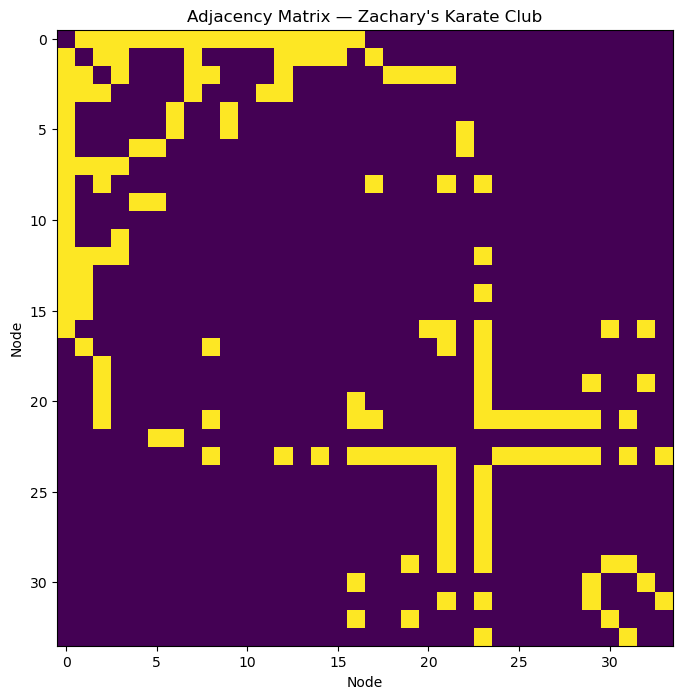

In [128]:
plt.figure(figsize=(8, 8))
plt.imshow(adjacency_df, interpolation="nearest", aspect="equal")
plt.title("Adjacency Matrix — Zachary's Karate Club")
plt.xlabel("Node")
plt.ylabel("Node")
plt.show()

## <font color="red"><b>Exercise 7</b></font>

1. Why is the adjacency matrix symmetric?
2. Why should its diagonal contain zeros?
3. Find $A_{ij}$ for one pair of connected nodes and one pair of unconnected nodes.
4. Explain how the degree of a node can be obtained from one row of the adjacency matrix.

## 6.0. Clustering coefficient

In a social network, a high clustering coefficient suggests a tightly interconnected local friendship circle.
Equivalent definitions 
- The *clustering coefficient* measures the tendency of a node's neighbors to be connected to one another.
- The *local clustering coefficient* of a node $i$ measures how close its neighbours are to forming a complete clique:


For node $i$,

$C_i = \frac{2T_i}{k_i(k_i-1)}$


where:

- $T_i$ = $T_i$ is the number of triangles that include $i$,
- $k_i$ = degree of node $i$.


The *global clustering coefficient* (or average clustering) is the mean of $C_i$ over all nodes.


### 6.1. Why clustering matters: real-world intuition

The clustering coefficient is particularly meaningful in social systems because social relationships often form **triangles**.

### Intuition
- **Friendship / school networks:** if Alice is friends with Bob and Alice is friends with Carol, Bob and Carol are also more likely to know each other.
- **Workplace networks:** people in the same project team or department often form densely connected local groups.
- **Scientific collaboration:** if researcher A collaborates with both B and C, B and C may also collaborate.
- **Online social networks:** mutual-friend recommendations exploit this tendency toward triangle closure.
- **Karate Club:** members of the same social faction form many triangles, so local clustering can reveal cohesive neighborhoods.
- **Contrast case – pure random or technological networks**  
   - Power-grid connections or random Erdős–Rényi graphs have clustering close to zero.  
   - Internet router graphs also show low clustering.  

A high clustering coefficient therefore indicates **local cohesion**: a node's neighbors tend to be connected with one another rather than forming independent relationships only through the focal node.


###  Below is an example of why the clustering coefficient matters for understanding a network.
How many **triangles** can be expected in:
- Frienship network
- Romantic network.
- Small World Model

<div style="display: flex; justify-content: space-around; align-items: center;">
    <img src="ClusteringCoeff.png" width="30%">
    <img src="SocialNetworksAuthors.png" width="25%">
    <img src="connected.jpg" width="5%">
     <img src="SmallWorld.jpg" width="40%">
</div>

#### 6.2 Triangles that involve each node

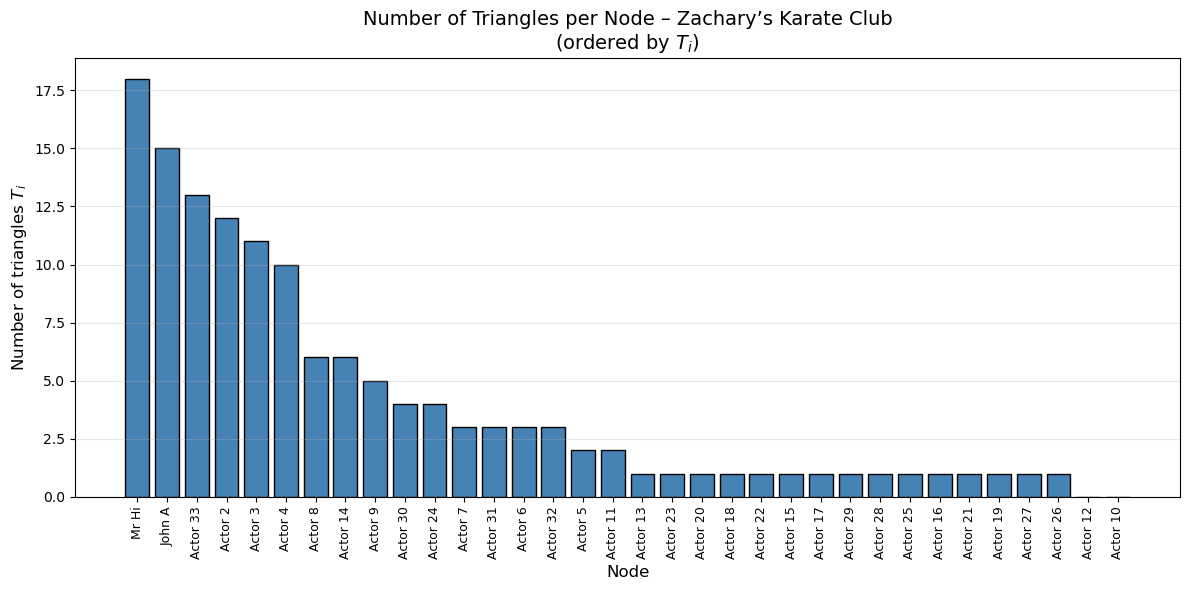

In [129]:
# Number of triangles T_i for each node (triangles including node i)
triangles = nx.triangles(G)
tri_series = pd.Series(triangles).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Bar plot (histogram-style) of number of triangles per node
bars = plt.bar(range(len(tri_series)), tri_series.values, color="steelblue", edgecolor="black")

# Vertical node labels
plt.xticks(range(len(tri_series)), tri_series.index, rotation=90, fontsize=9)

plt.ylabel("Number of triangles $T_i$", fontsize=12)
plt.xlabel("Node", fontsize=12)
plt.title("Number of Triangles per Node – Zachary’s Karate Club\n(ordered by $T_i$)", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### 6.2  Compute the clustering coefficient.
- i.e. divide by ${k_i(k_i-1)}/2$
- What is the meaning of ${k_i(k_i-1)}/2$?

In [130]:
node_metrics = (
    pd.DataFrame({
        "node": list(G.nodes()),
        "degree": [G.degree(n) for n in G.nodes()],
        "clustering_coefficient": [nx.clustering(G, n) for n in G.nodes()]
    })
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)

node_metrics.head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
node,John A,Mr Hi,Actor 33,Actor 3,Actor 2,Actor 4,Actor 32,Actor 24,Actor 14,Actor 9,Actor 31,Actor 7,Actor 8,Actor 30,Actor 28
degree,17,16,12,10,9,6,6,5,5,5,4,4,4,4,4
clustering_coefficient,0.110294,0.15,0.19697,0.244444,0.333333,0.666667,0.2,0.4,0.6,0.5,0.5,0.5,1.0,0.666667,0.166667


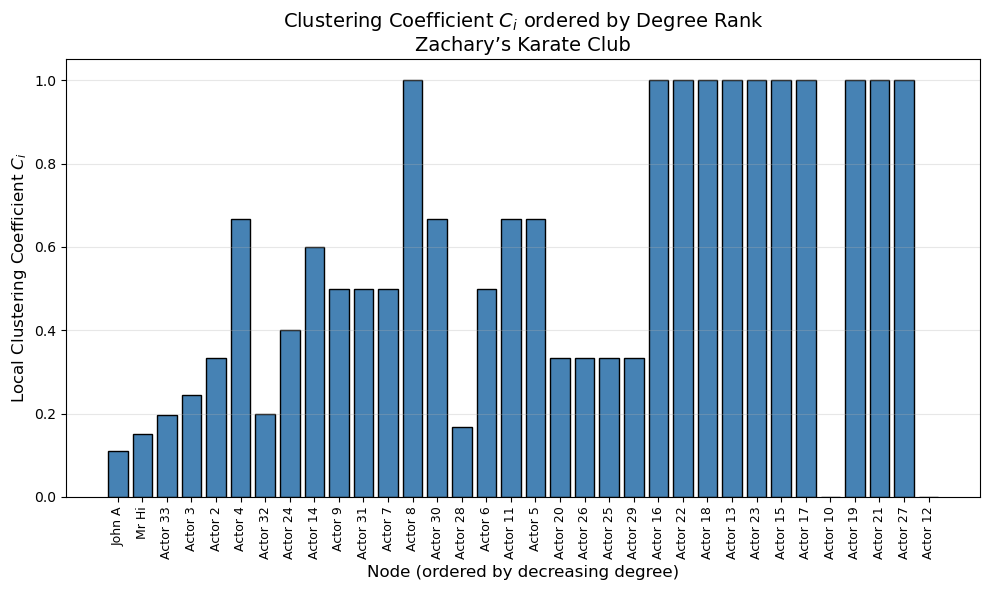

In [131]:


# Ensure the table is sorted by degree (descending)
node_metrics_sorted = node_metrics.sort_values("degree", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))

# Bar plot of clustering coefficient
plt.bar(range(len(node_metrics_sorted)), 
        node_metrics_sorted["clustering_coefficient"], 
        color="steelblue", edgecolor="black")

# Vertical node labels on the x-axis
plt.xticks(range(len(node_metrics_sorted)), 
           node_metrics_sorted["node"], 
           rotation=90, fontsize=9)

plt.ylabel(r"Local Clustering Coefficient $C_i$", fontsize=12)
plt.xlabel("Node (ordered by decreasing degree)", fontsize=12)
plt.title(r"Clustering Coefficient $C_i$ ordered by Degree Rank" + "\nZachary’s Karate Club", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

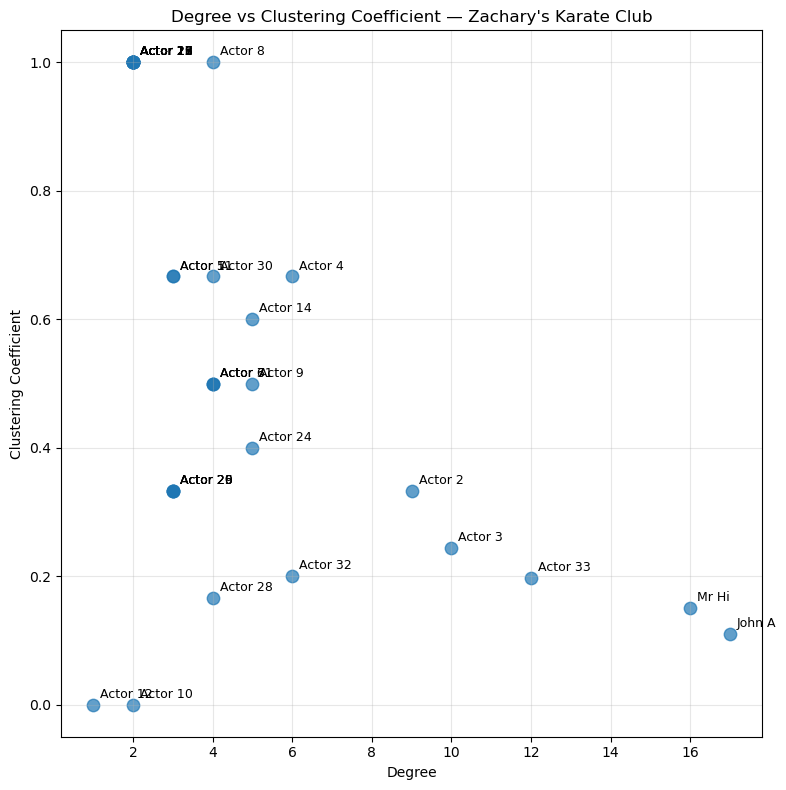

In [132]:
# Scatter plot: Degree vs Clustering Coefficient

plt.figure(figsize=(8, 8))

plt.scatter(
    node_metrics["degree"],
    node_metrics["clustering_coefficient"],
    s=80,
    alpha=0.7
)

# Add the node label to each point
for _, row in node_metrics.iterrows():
    plt.annotate(
        row["node"],
        (row["degree"], row["clustering_coefficient"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Degree")
plt.ylabel("Clustering Coefficient")
plt.title("Degree vs Clustering Coefficient — Zachary's Karate Club")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercise 8</b></font>

1. Explain to yourself your own words what is the clustering coefficient.
2. Find one node with high clustering and one node with low clustering and Explain the social meaning of these two cases.
3. Check the plot Degree vs Clustering Coefficient.  Provide a qualitative explanation of why the influencer measure, in the sense of number of followers is different from the fact that someone is integrated in the community. *Important*: **Trust** is important, argue why a high cluster indicates more trust.
4. Can a node have high degree and relatively low clustering? What would that imply about its local position?

## 7.0. Network visualization

A network drawing is not the network itself: it is a **two-dimensional representation** of the graph.

NetworkX layout algorithms assign coordinates to nodes. A force-directed layout such as `spring_layout()` places connected nodes closer while attempting to reduce visual overlap.

The positions therefore help reveal structure, but distances in the drawing should not automatically be interpreted as physical distances.

**Objective:** Learn different ways of representing a graph, each provides a different perspective.

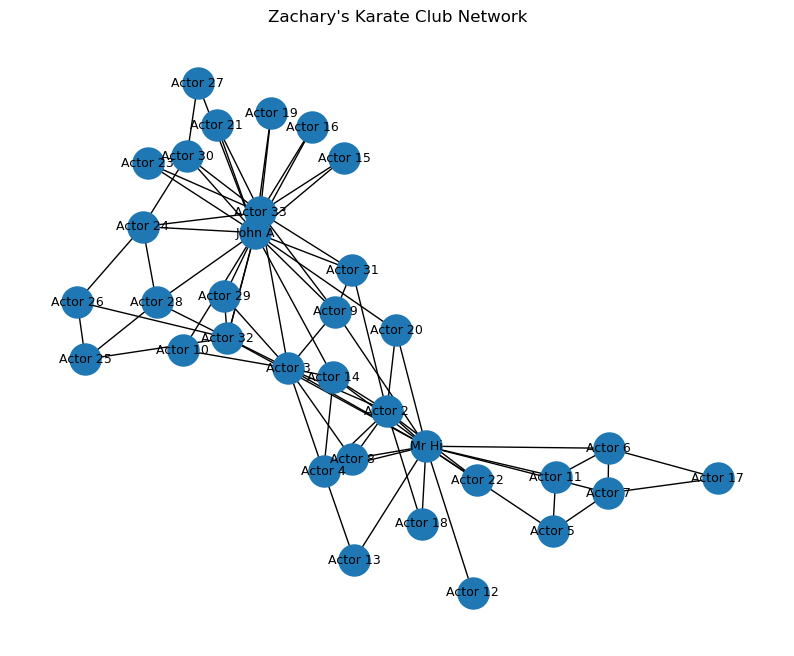

In [133]:
# Reproducible force-directed layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=500,
    font_size=9,
    width=1.0
)

plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

### 7.1. Visualization with node size proportional to degree

Changing node size according to degree makes highly connected members easier to identify.

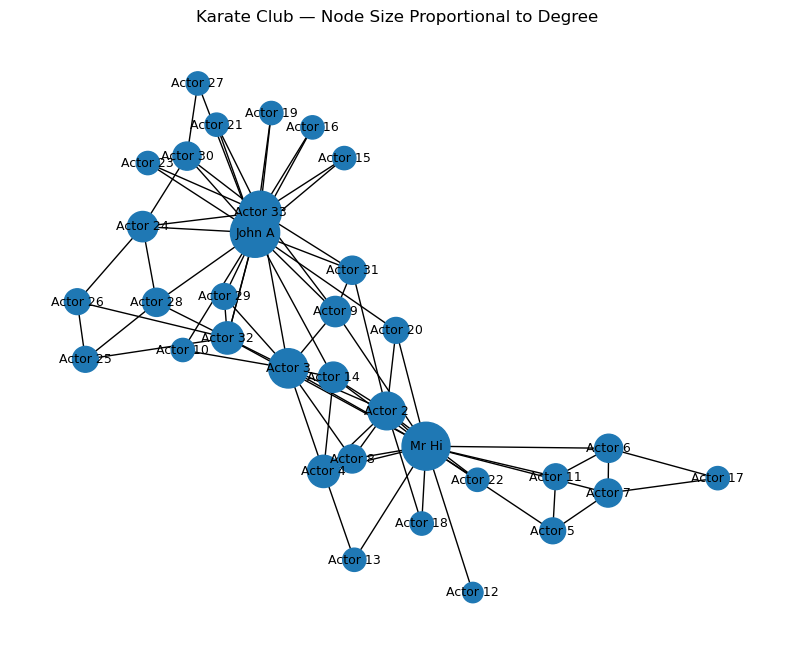

In [134]:
degrees = dict(G.degree())
node_sizes = [150 + 65 * degrees[node] for node in G.nodes()]

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Node Size Proportional to Degree")
plt.axis("off")
plt.show()

### 7.2. Alternative visualization: size and color proportional to degree

The same structural quantity can be encoded by more than one visual channel. Here, both **node size** and **node color** represent degree. Highly connected members therefore become visually prominent.

This is useful for exploratory analysis, but remember that a visual encoding is an aid to interpretation; quantitative conclusions should still be based on computed network measures.

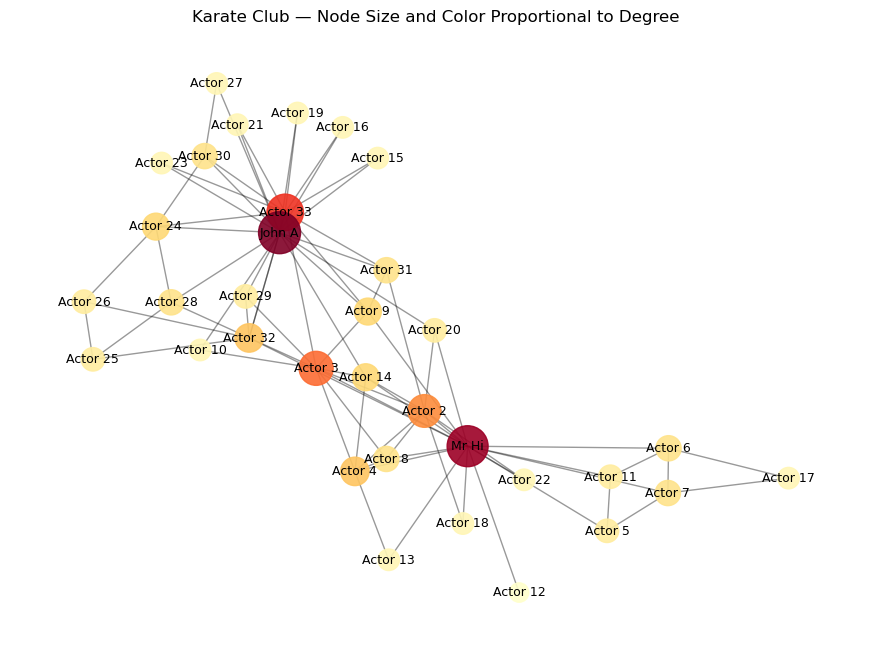

In [135]:
degrees = dict(G.degree())
node_sizes = [150 + 45 * degrees[node] for node in G.nodes()]
node_colors = [degrees[node] for node in G.nodes()]

plt.figure(figsize=(11, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club — Node Size and Color Proportional to Degree")
plt.axis("off")
plt.show()

### 7.2. Visualization with node size proportional to clustering coefficient

This view emphasizes a different structural property: local cohesion rather than number of contacts.

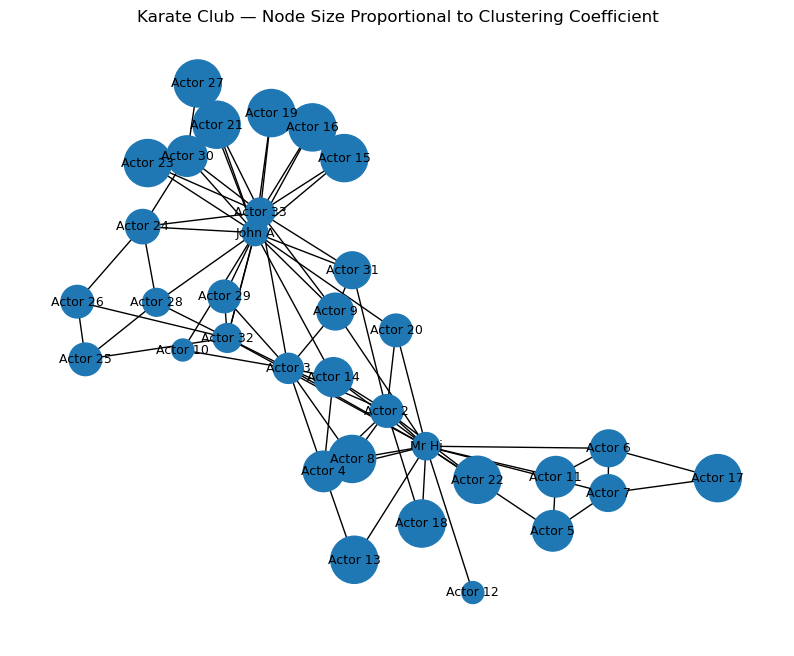

In [136]:
node_sizes_clustering = [
    250 + 900 * clustering[node]
    for node in G.nodes()
]

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=node_sizes_clustering,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Node Size Proportional to Clustering Coefficient")
plt.axis("off")
plt.show()

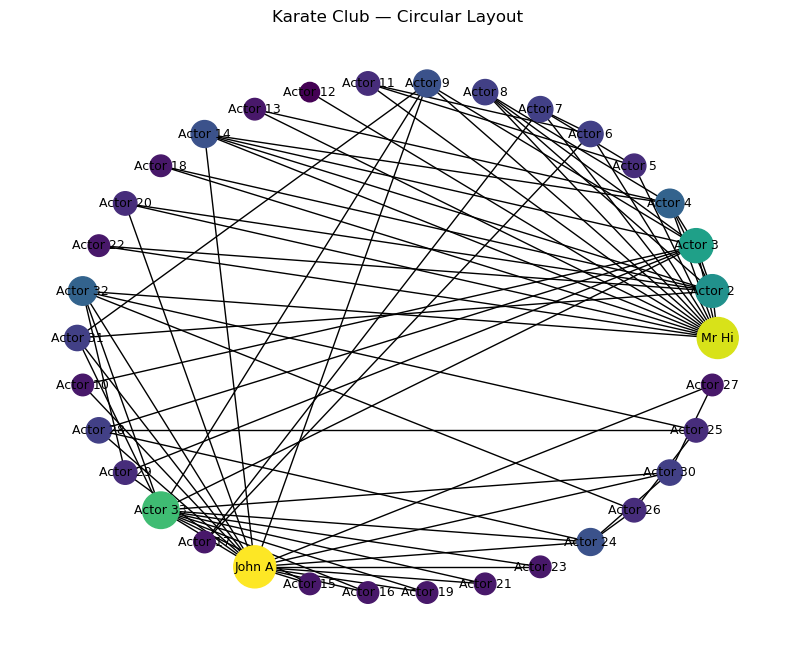

In [137]:
# Circular layout visualization
plt.figure(figsize=(10, 8))
pos_circle = nx.circular_layout(G)

# Node sizes and colours proportional to degree for readability
degrees = dict(G.degree())
node_sizes_circle = [150 + 45 * degrees[node] for node in G.nodes()]
node_colors_circle = [degrees[node] for node in G.nodes()]

nx.draw_networkx(
    G,
    pos=pos_circle,
    with_labels=True,
    node_size=node_sizes_circle,
    node_color=node_colors_circle,
    cmap=plt.cm.viridis,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Circular Layout")
plt.axis("off")
plt.show()

## <font color="red"><b>Exercise 9</b></font>

Compare the two previous figures.

1. Which nodes look important when size represents **degree**?
2. Which nodes look important when size represents **clustering coefficient**?
3. Why are the two concepts not equivalent?
4. Describe in 4–6  the club is likely to break down, from the different kind of graph representations.

## <font color="red"><b>Exercise 10 — Infographic</b></font>

Create a **one-page infographic** entitled:

### *From Data to Graphs: Zachary's Karate Club*

It should visually explain in an easy to understand graphical way, the problem tackled in the practice.

## <font color="red"><b>Exercise 11 — Executive Summary</b></font>

Write an **executive summary of approximately 250–350 words** that could be understood by a reader who is short of time, and wants to get the idea of what was done.